In [1]:
import pandas as pd
df = pd.read_csv('upi_transactions_2024.csv')
print("Shape:", df.shape)
df.head()

Shape: (5020, 9)


,transaction_id,user_id,timestamp,payment_method,amount,status,city,merchant_category,device_type
0,T000001,U0103,2024-09-25 12:36:44,UPI,318.58,Success,Hyderabad,Entertainment,Android
1,T000002,U0131,2024-09-03 12:54:45,UPI,501.95,Success,Mumbai,Healthcare,Android
2,T000003,U0345,2024-04-17 16:54:08,Wallet,71.00,Success,Pune,Fuel,Android
3,T000004,U0244,2024-11-17 23:26:55,UPI,3291.83,Success,Pune,Grocery,Android
4,T000005,U0346,2024-07-13 23:16:04,UPI,357.47,Success,Chennai,Entertainment,Android


In [47]:
# ============================================
# LEADERSHIP QUESTIONS - COMPLETE ANALYSIS
# ============================================

df['is_failed'] = (df['status'] == 'Failed').astype(int)

print("="*60)
print("Q1: WHICH PAYMENT METHODS ARE USED MOST?")
print("="*60)
method_usage = df.groupby('payment_method').agg(
    transaction_count=('transaction_id', 'count'),
    total_volume=('amount', 'sum')
).sort_values('transaction_count', ascending=False)
method_usage['usage_pct'] = (method_usage['transaction_count'] / method_usage['transaction_count'].sum() * 100).round(2)
print(method_usage)
most_used = method_usage['transaction_count'].idxmax()
print(f"\n>> ANSWER: '{most_used}' is used most - {method_usage.loc[most_used,'transaction_count']} transactions ({method_usage.loc[most_used,'usage_pct']}%)")


print("\n" + "="*60)
print("Q2: WHEN DO TRANSACTION FAILURES INCREASE?")
print("="*60)
failure_by_hour = (df.groupby('hour')['is_failed'].mean() * 100).round(2).sort_values(ascending=False)
print("Failure rate by hour (top 5 riskiest):")
print(failure_by_hour.head(5))
worst_hour = failure_by_hour.idxmax()

failure_by_day = (df.groupby('day_name')['is_failed'].mean() * 100).round(2).sort_values(ascending=False)
print("\nFailure rate by day:")
print(failure_by_day)
worst_day = failure_by_day.idxmax()
print(f"\n>> ANSWER: Failures increase most at {worst_hour}:00 hour, and on {worst_day}s")


print("\n" + "="*60)
print("Q3: WHICH CUSTOMER SEGMENTS GENERATE HIGHEST REVENUE?")
print("="*60)
if 'segment' not in df.columns:
    user_summary = df.groupby('user_id').agg(
        total_transactions=('transaction_id', 'count'),
        total_spend=('amount', 'sum')
    ).reset_index()
    txn_high = user_summary['total_transactions'].quantile(0.75)
    spend_high = user_summary['total_spend'].quantile(0.75)
    txn_low = user_summary['total_transactions'].quantile(0.25)

    def assign_segment(row):
        if row['total_transactions'] >= txn_high and row['total_spend'] >= spend_high:
            return 'Heavy + High-Value User'
        elif row['total_transactions'] >= txn_high:
            return 'Heavy User'
        elif row['total_spend'] >= spend_high:
            return 'High-Value User'
        elif row['total_transactions'] <= txn_low:
            return 'Low-Engagement User'
        else:
            return 'Regular / Frequent Transactor'

    user_summary['segment'] = user_summary.apply(assign_segment, axis=1)
    df = df.merge(user_summary[['user_id', 'segment']], on='user_id', how='left')

segment_revenue = df.groupby('segment')['amount'].sum().sort_values(ascending=False)
print(segment_revenue)
top_segment = segment_revenue.idxmax()
print(f"\n>> ANSWER: '{top_segment}' segment generates highest revenue: Rs.{segment_revenue.max():,.2f}")


print("\n" + "="*60)
print("Q4: WHAT TRANSACTION PATTERNS INDICATE OPERATIONAL PROBLEMS?")
print("="*60)
high_value_threshold = df['amount'].quantile(0.90)
high_value_failures = df[(df['amount'] >= high_value_threshold) & (df['status']=='Failed')].shape[0]
device_failure = (df.groupby('device_type')['is_failed'].mean()*100).round(2).sort_values(ascending=False)

print(f"High-value transactions that failed: {high_value_failures}")
print(f"\nFailure rate by device type:")
print(device_failure)
print(f"\nOverall failure rate: {(df['is_failed'].mean()*100):.2f}%")
print(f"\n>> ANSWER: Problem patterns -> high failure rate at peak hour {worst_hour}:00, "
      f"device '{device_failure.idxmax()}' has highest failure rate ({device_failure.max()}%), "
      f"and {high_value_failures} high-value transactions failed (potential fraud/risk signal)")


print("\n" + "="*60)
print("Q5: WHICH REGIONS REQUIRE ATTENTION?")
print("="*60)
region_performance = df.groupby('city').agg(
    transaction_count=('transaction_id', 'count'),
    failure_rate=('is_failed', lambda x: x.mean()*100),
    total_volume=('amount', 'sum')
).round(2).sort_values('failure_rate', ascending=False)
print(region_performance)
worst_region = region_performance['failure_rate'].idxmax()
print(f"\n>> ANSWER: '{worst_region}' requires attention - highest failure rate: {region_performance.loc[worst_region,'failure_rate']}%")

Q1: WHICH PAYMENT METHODS ARE USED MOST?
                transaction_count  total_volume  usage_pct
payment_method                                            
UPI                          2410   4905703.415      48.20
Card                         1029   2416751.535      20.58
Wallet                        759   1806302.560      15.18
NetBanking                    528   1093793.680      10.56
QR                            274    476919.430       5.48

>> ANSWER: 'UPI' is used most - 2410 transactions (48.2%)

Q2: WHEN DO TRANSACTION FAILURES INCREASE?
Failure rate by hour (top 5 riskiest):
hour
9     12.87
13    11.65
8     10.86
0     10.80
4     10.55
Name: is_failed, dtype: float64

Failure rate by day:
day_name
Tuesday      9.71
Thursday     9.14
Sunday       9.05
Wednesday    9.02
Friday       8.99
Monday       8.04
Saturday     7.16
Name: is_failed, dtype: float64

>> ANSWER: Failures increase most at 9:00 hour, and on Tuesdays

Q3: WHICH CUSTOMER SEGMENTS GENERATE HIGHEST REVENUE

In [2]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     5020 non-null   object 
 1   user_id            5020 non-null   object 
 2   timestamp          5020 non-null   object 
 3   payment_method     5020 non-null   object 
 4   amount             4970 non-null   float64
 5   status             5020 non-null   object 
 6   city               5020 non-null   object 
 7   merchant_category  5020 non-null   object 
 8   device_type        4990 non-null   object 
dtypes: float64(1), object(8)
memory usage: 353.1+ KB

Missing values per column:
transaction_id        0
user_id               0
timestamp             0
payment_method        0
amount               50
status                0
city                  0
merchant_category     0
device_type          30
dtype: int64


In [48]:
df['amount'] = df['amount'].fillna(df['amount'].median())

if df['device_type'].isnull().sum() > 0:
    df['device_type'] = df['device_type'].fillna(df['device_type'].mode()[0])

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
transaction_id       0
user_id              0
timestamp            0
payment_method       0
amount               0
status               0
city                 0
merchant_category    0
device_type          0
hour                 0
day_name             0
month_name           0
date                 0
peak_hour_flag       0
high_value_flag      0
user_failure_rate    0
daily_txn_count      0
is_failed            0
segment              0
dtype: int64


In [4]:
before = df.shape[0]
df = df.drop_duplicates(subset='transaction_id')
after = df.shape[0]
print(f"Removed {before - after} duplicate rows")
print("New shape:", df.shape)

Removed 20 duplicate rows
New shape: (5000, 9)


In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day_name'] = df['timestamp'].dt.day_name()
df['month_name'] = df['timestamp'].dt.month_name()
df['date'] = df['timestamp'].dt.date

df[['timestamp', 'hour', 'day_name', 'month_name', 'date']].head()

,timestamp,hour,day_name,month_name,date
0,2024-09-25 12:36:44,12,Wednesday,September,2024-09-25
1,2024-09-03 12:54:45,12,Tuesday,September,2024-09-03
2,2024-04-17 16:54:08,16,Wednesday,April,2024-04-17
3,2024-11-17 23:26:55,23,Sunday,November,2024-11-17
4,2024-07-13 23:16:04,23,Saturday,July,2024-07-13


In [6]:
# Peak Hour Flag
peak_hours = [10, 11, 12, 13, 14, 18, 19, 20, 21]
df['peak_hour_flag'] = df['hour'].apply(lambda x: 1 if x in peak_hours else 0)

# High-Value Transaction Flag (top 10%)
threshold = df['amount'].quantile(0.90)
df['high_value_flag'] = df['amount'].apply(lambda x: 1 if x >= threshold else 0)
print(f"High value threshold: {threshold:.2f}")

# Failure Rate Indicator (per user)
user_failure_rate = df.groupby('user_id')['status'].apply(lambda x: (x == 'Failed').mean())
df['user_failure_rate'] = df['user_id'].map(user_failure_rate)

# Daily Usage Score
daily_usage = df.groupby(['user_id', 'date']).size().reset_index(name='daily_txn_count')
df = df.merge(daily_usage, on=['user_id', 'date'], how='left')

df[['peak_hour_flag', 'high_value_flag', 'user_failure_rate', 'daily_txn_count']].head()

High value threshold: 2990.30


,peak_hour_flag,high_value_flag,user_failure_rate,daily_txn_count
0,1,0,0.000000,1
1,1,0,0.111111,1
2,0,0,0.000000,1
3,0,1,0.181818,1
4,0,0,0.176471,1


In [7]:
df.to_csv('cleaned_upi_transactions.csv', index=False)
print("Cleaned dataset saved. Final shape:", df.shape)
df.head()

Cleaned dataset saved. Final shape: (5000, 17)


,transaction_id,user_id,timestamp,payment_method,amount,status,city,merchant_category,device_type,hour,day_name,month_name,date,peak_hour_flag,high_value_flag,user_failure_rate,daily_txn_count
0,T000001,U0103,2024-09-25 12:36:44,UPI,318.58,Success,Hyderabad,Entertainment,Android,12,Wednesday,September,2024-09-25,1,0,0.000000,1
1,T000002,U0131,2024-09-03 12:54:45,UPI,501.95,Success,Mumbai,Healthcare,Android,12,Tuesday,September,2024-09-03,1,0,0.111111,1
2,T000003,U0345,2024-04-17 16:54:08,Wallet,71.00,Success,Pune,Fuel,Android,16,Wednesday,April,2024-04-17,0,0,0.000000,1
3,T000004,U0244,2024-11-17 23:26:55,UPI,3291.83,Success,Pune,Grocery,Android,23,Sunday,November,2024-11-17,0,1,0.181818,1
4,T000005,U0346,2024-07-13 23:16:04,UPI,357.47,Success,Chennai,Entertainment,Android,23,Saturday,July,2024-07-13,0,0,0.176471,1


In [9]:
# ============ KPI DASHBOARD - PYTHON ============

print("="*50)
print("DIGITAL PAYMENT ANALYTICS - KPI REPORT")
print("="*50)

# 1. Total Transactions
total_transactions = len(df)
print(f"\n1. Total Transactions: {total_transactions}")

# 2. Total Payment Volume
total_volume = df['amount'].sum()
print(f"2. Total Payment Volume: Rs. {total_volume:,.2f}")

# 3. Success Rate
success_rate = (df['status'] == 'Success').mean() * 100
print(f"3. Success Rate: {success_rate:.2f}%")

# 4. Failure Rate
failure_rate = (df['status'] == 'Failed').mean() * 100
print(f"4. Failure Rate: {failure_rate:.2f}%")

# 5. Average Transaction Value
avg_txn_value = df['amount'].mean()
print(f"5. Average Transaction Value: Rs. {avg_txn_value:.2f}")

# 6. Peak Transaction Hour
peak_hour = df.groupby('hour').size().idxmax()
print(f"6. Peak Transaction Hour: {peak_hour}:00")

# 7. Active Users
active_users = df['user_id'].nunique()
print(f"7. Active Users: {active_users}")

# 8. Revenue Contribution by Payment Method
print(f"\n8. Revenue Contribution by Payment Method:")
revenue_by_method = df.groupby('payment_method')['amount'].sum().sort_values(ascending=False)
revenue_pct = (revenue_by_method / revenue_by_method.sum() * 100).round(2)
for method, revenue in revenue_by_method.items():
    print(f"   {method}: Rs. {revenue:,.2f} ({revenue_pct[method]}%)")

DIGITAL PAYMENT ANALYTICS - KPI REPORT

1. Total Transactions: 5000
2. Total Payment Volume: Rs. 10,699,470.62
3. Success Rate: 87.94%
4. Failure Rate: 8.74%
5. Average Transaction Value: Rs. 2139.89
6. Peak Transaction Hour: 12:00
7. Active Users: 500

8. Revenue Contribution by Payment Method:
   UPI: Rs. 4,905,703.42 (45.85%)
   Card: Rs. 2,416,751.54 (22.59%)
   Wallet: Rs. 1,806,302.56 (16.88%)
   NetBanking: Rs. 1,093,793.68 (10.22%)
   QR: Rs. 476,919.43 (4.46%)


In [10]:
kpi_summary = pd.DataFrame({
    'KPI': ['Total Transactions', 'Total Payment Volume', 'Success Rate', 
            'Failure Rate', 'Avg Transaction Value', 'Peak Hour', 'Active Users'],
    'Value': [total_transactions, f"Rs.{total_volume:,.2f}", f"{success_rate:.2f}%",
              f"{failure_rate:.2f}%", f"Rs.{avg_txn_value:.2f}", f"{peak_hour}:00", active_users]
})

print(kpi_summary)

# Save as CSV report
kpi_summary.to_csv('kpi_report.csv', index=False)
print("\nKPI report saved as kpi_report.csv")

                     KPI             Value
0     Total Transactions              5000
1   Total Payment Volume  Rs.10,699,470.62
2           Success Rate            87.94%
3           Failure Rate             8.74%
4  Avg Transaction Value        Rs.2139.89
5              Peak Hour             12:00
6           Active Users               500

KPI report saved as kpi_report.csv


In [12]:
# ============================================
# PAYMENT HEALTH KPIs
# ============================================
print("="*55)
print("PAYMENT HEALTH KPIs (System reliability & business health)")
print("="*55)

success_rate = (df['status'] == 'Success').mean() * 100
failure_rate = (df['status'] == 'Failed').mean() * 100
avg_txn_value = df['amount'].mean()
total_volume = df['amount'].sum()

print(f"1. Success Rate           : {success_rate:.2f}%")
print(f"2. Failure Rate            : {failure_rate:.2f}%")
print(f"3. Avg Transaction Value   : Rs. {avg_txn_value:.2f}")
print(f"4. Total Payment Volume    : Rs. {total_volume:,.2f}")

print("\nRevenue Contribution by Payment Method:")
revenue_by_method = df.groupby('payment_method')['amount'].sum().sort_values(ascending=False)
revenue_pct = (revenue_by_method / revenue_by_method.sum() * 100).round(2)
for method, rev in revenue_by_method.items():
    print(f"   - {method}: Rs. {rev:,.2f} ({revenue_pct[method]}%)")


# ============================================
# OPERATIONS KPIs
# ============================================
print("\n" + "="*55)
print("OPERATIONS KPIs (Monitoring, alerts, troubleshooting)")
print("="*55)

peak_hour = df.groupby('hour').size().idxmax()
print(f"1. Peak Transaction Hour   : {peak_hour}:00")

# Fixed: create a helper column instead of using apply on groupby
df['is_failed'] = (df['status'] == 'Failed').astype(int)

print("\n2. Failure Rate by Hour (top 5 riskiest hours):")
failure_by_hour = (df.groupby('hour')['is_failed'].mean() * 100).sort_values(ascending=False)
print(failure_by_hour.head(5).round(2))

high_value_count = df['high_value_flag'].sum() if 'high_value_flag' in df.columns else (df['amount'] >= df['amount'].quantile(0.90)).sum()
print(f"\n3. High-Value Transactions Count : {high_value_count}")

print("\n4. Transaction Count by City (operational load per region):")
city_txns = df.groupby('city').size().sort_values(ascending=False)
print(city_txns)

print("\n5. Failure Rate by Device Type:")
failure_by_device = (df.groupby('device_type')['is_failed'].mean() * 100).sort_values(ascending=False)
print(failure_by_device.round(2))

PAYMENT HEALTH KPIs (System reliability & business health)
1. Success Rate           : 87.94%
2. Failure Rate            : 8.74%
3. Avg Transaction Value   : Rs. 2139.89
4. Total Payment Volume    : Rs. 10,699,470.62

Revenue Contribution by Payment Method:
   - UPI: Rs. 4,905,703.42 (45.85%)
   - Card: Rs. 2,416,751.54 (22.59%)
   - Wallet: Rs. 1,806,302.56 (16.88%)
   - NetBanking: Rs. 1,093,793.68 (10.22%)
   - QR: Rs. 476,919.43 (4.46%)

OPERATIONS KPIs (Monitoring, alerts, troubleshooting)
1. Peak Transaction Hour   : 12:00

2. Failure Rate by Hour (top 5 riskiest hours):
hour
9     12.87
13    11.65
8     10.86
0     10.80
4     10.55
Name: is_failed, dtype: float64

3. High-Value Transactions Count : 500

4. Transaction Count by City (operational load per region):
city
Hyderabad    687
Pune         646
Ahmedabad    632
Kolkata      623
Chennai      616
Bangalore    605
Mumbai       597
Delhi        594
dtype: int64

5. Failure Rate by Device Type:
device_type
iOS        9.80
And

In [18]:
import os
os.makedirs('images', exist_ok=True)
print("images folder ready:", os.path.exists('images'))

images folder ready: True


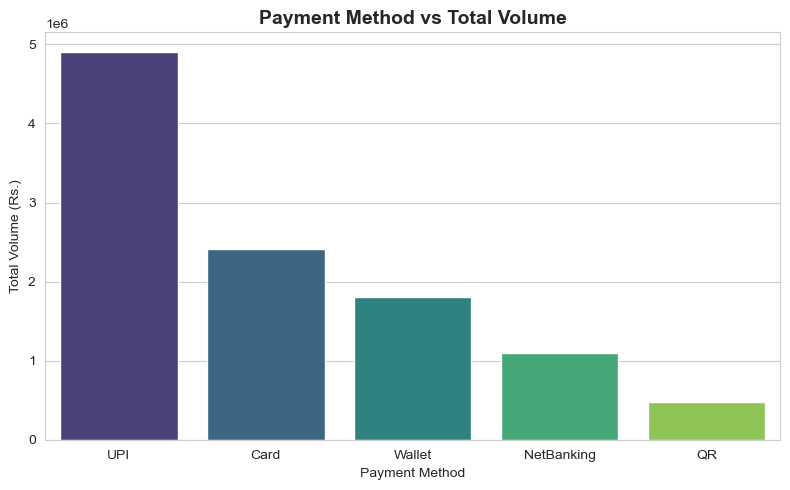

payment_method
UPI           4905703.415
Card          2416751.535
Wallet        1806302.560
NetBanking    1093793.680
QR             476919.430
Name: amount, dtype: float64


In [22]:
payment_volume = df.groupby('payment_method')['amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=payment_volume.index, y=payment_volume.values, hue=payment_volume.index, palette='viridis', legend=False)
plt.title('Payment Method vs Total Volume', fontsize=14, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Total Volume (Rs.)')
plt.tight_layout()
plt.savefig('images/payment_method_vs_volume.png', dpi=150)
plt.show()

print(payment_volume)

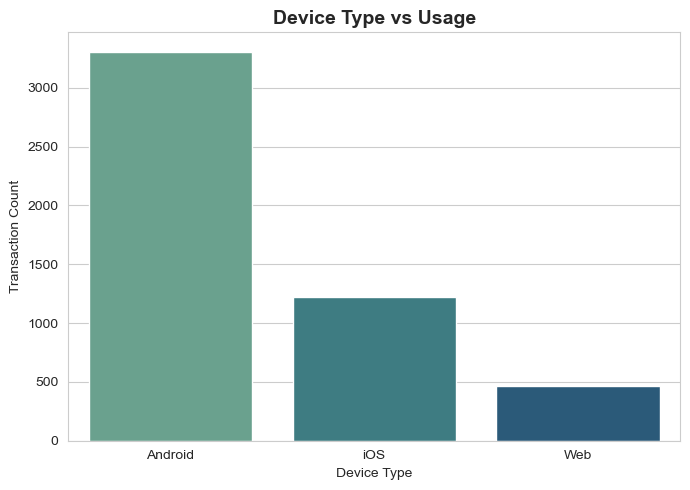

device_type
Android    3307
iOS        1225
Web         468
dtype: int64


In [28]:
device_usage = df.groupby('device_type').size().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=device_usage.index, y=device_usage.values, hue=device_usage.index, palette='crest', legend=False)
plt.title('Device Type vs Usage', fontsize=14, fontweight='bold')
plt.xlabel('Device Type')
plt.ylabel('Transaction Count')
plt.tight_layout()
plt.savefig('images/device_type_vs_usage.png', dpi=150)
plt.show()

print(device_usage)

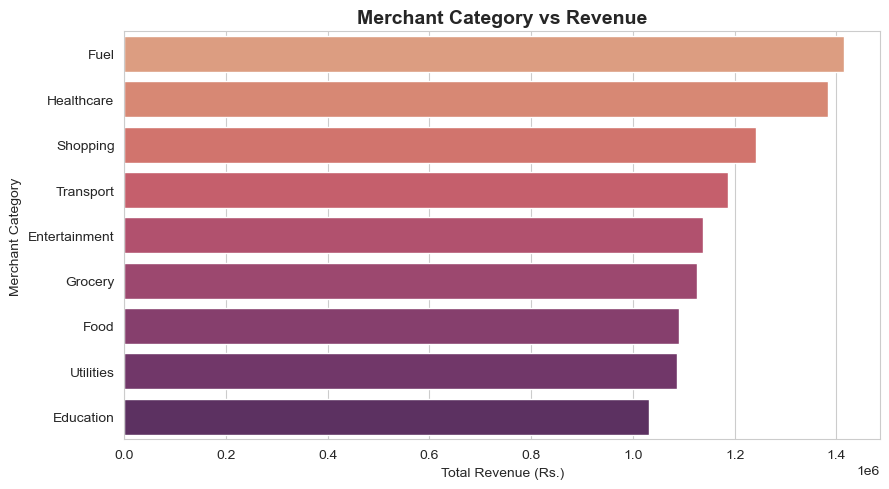

merchant_category
Fuel             1414939.665
Healthcare       1383910.585
Shopping         1242158.415
Transport        1187198.145
Entertainment    1137469.600
Grocery          1125591.600
Food             1090081.920
Utilities        1087559.495
Education        1030561.195
Name: amount, dtype: float64


In [29]:
category_revenue = df.groupby('merchant_category')['amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x=category_revenue.values, y=category_revenue.index, hue=category_revenue.index, palette='flare', orient='h', legend=False)
plt.title('Merchant Category vs Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Total Revenue (Rs.)')
plt.ylabel('Merchant Category')
plt.tight_layout()
plt.savefig('images/merchant_category_vs_revenue.png', dpi=150)
plt.show()

print(category_revenue)

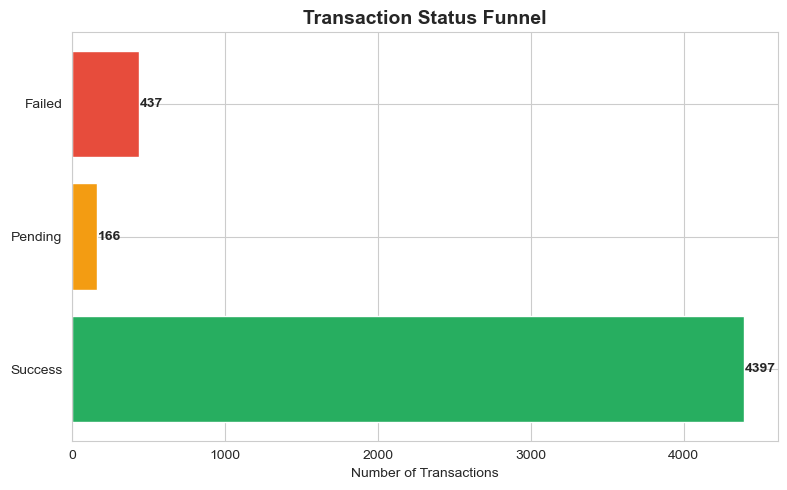

In [32]:
funnel_data = df['status'].value_counts()
funnel_order = ['Success', 'Pending', 'Failed']
funnel_values = [funnel_data.get(s, 0) for s in funnel_order]

plt.figure(figsize=(8, 5))
plt.barh(funnel_order, funnel_values, color=['#27ae60', '#f39c12', '#e74c3c'])
plt.title('Transaction Status Funnel', fontsize=14, fontweight='bold')
plt.xlabel('Number of Transactions')
for i, v in enumerate(funnel_values):
    plt.text(v + 5, i, str(v), va='center', fontweight='bold')
plt.tight_layout()
plt.savefig('images/status_funnel.png', dpi=150)
plt.show()

In [33]:
print("="*55)
print("BUSINESS QUESTION ANSWERS")
print("="*55)

top_method = payment_volume.idxmax()
print(f"\n1. Which payment method dominates?")
print(f"   -> {top_method} dominates with Rs.{payment_volume.max():,.2f} total volume")

worst_hour = failure_by_hour.idxmax()
print(f"\n2. When do failures spike?")
print(f"   -> Failures spike at {worst_hour}:00 hour with {failure_by_hour.max():.2f}% failure rate")

top_category = category_revenue.idxmax()
print(f"\n3. Which category generates highest volume?")
print(f"   -> {top_category} generates highest revenue: Rs.{category_revenue.max():,.2f}")

BUSINESS QUESTION ANSWERS

1. Which payment method dominates?
   -> UPI dominates with Rs.4,905,703.42 total volume

2. When do failures spike?
   -> Failures spike at 9:00 hour with 12.87% failure rate

3. Which category generates highest volume?
   -> Fuel generates highest revenue: Rs.1,414,939.67


In [36]:
def assign_segment(row):
    if row['total_transactions'] >= txn_count_high and row['total_spend'] >= spend_high:
        return 'Heavy + High-Value User'
    elif row['total_transactions'] >= txn_count_high:
        return 'Heavy User'
    elif row['total_spend'] >= spend_high:
        return 'High-Value User'
    elif row['total_transactions'] <= txn_count_low:
        return 'Low-Engagement User'
    else:
        return 'Regular / Frequent Transactor'

user_summary['segment'] = user_summary.apply(assign_segment, axis=1)

print(user_summary['segment'].value_counts())

segment
Low-Engagement User              152
Regular / Frequent Transactor    125
Heavy User                        98
Heavy + High-Value User           64
High-Value User                   61
Name: count, dtype: int64


In [37]:
df = df.merge(user_summary[['user_id', 'segment']], on='user_id', how='left')
df[['user_id', 'segment']].head()

,user_id,segment
0,U0103,Regular / Frequent Transactor
1,U0131,Regular / Frequent Transactor
2,U0345,Low-Engagement User
3,U0244,Regular / Frequent Transactor
4,U0346,Heavy User


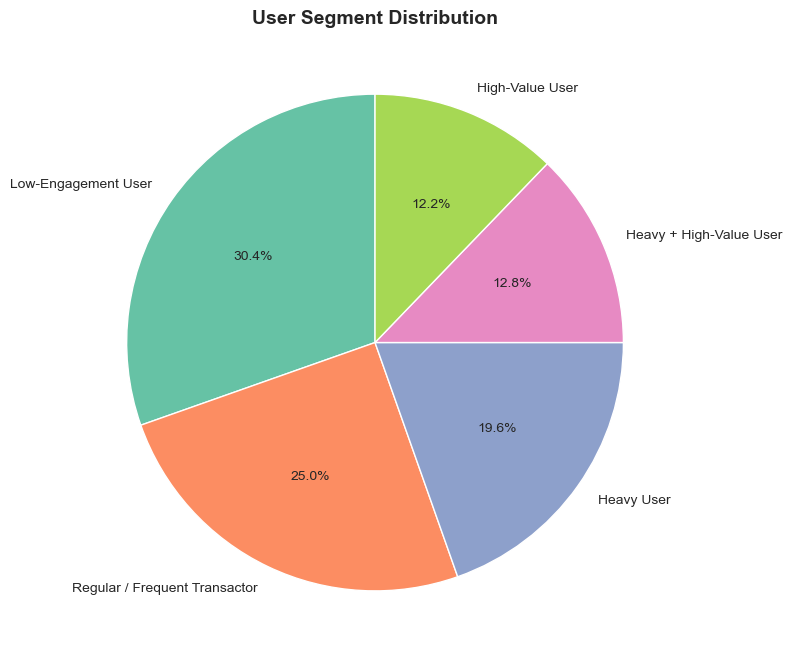

segment
Low-Engagement User              152
Regular / Frequent Transactor    125
Heavy User                        98
Heavy + High-Value User           64
High-Value User                   61
Name: count, dtype: int64


In [38]:
segment_counts = user_summary['segment'].value_counts()

plt.figure(figsize=(8, 8))
colors = sns.color_palette('Set2', len(segment_counts))
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('User Segment Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/user_segment_distribution.png', dpi=150)
plt.show()

print(segment_counts)

In [39]:
segment_analysis = user_summary.groupby('segment').agg(
    avg_transactions=('total_transactions', 'mean'),
    avg_total_spend=('total_spend', 'mean'),
    avg_txn_value=('avg_transaction_value', 'mean'),
    avg_failure_rate=('failure_rate', 'mean'),
    user_count=('user_id', 'count')
).round(2).sort_values('avg_total_spend', ascending=False)

print(segment_analysis)

                               avg_transactions  avg_total_spend  \
segment                                                            
Heavy + High-Value User                   14.08         44498.09   
High-Value User                            9.18         40146.29   
Heavy User                                13.29         18585.21   
Regular / Frequent Transactor              9.86         14435.56   
Low-Engagement User                        6.61         11689.95   

                               avg_txn_value  avg_failure_rate  user_count  
segment                                                                     
Heavy + High-Value User              3199.08              8.54          64  
High-Value User                      4493.12              8.39          61  
Heavy User                           1413.50             10.19          98  
Regular / Frequent Transactor        1474.62              8.00         125  
Low-Engagement User                  1731.71              8.0

In [41]:
user_summary.to_csv('user_segments.csv', index=False)
segment_analysis.to_csv('segment_analysis_report.csv')
print("Segment files saved successfully!")

Segment files saved successfully!


In [42]:
print("="*55)
print("USER SEGMENTATION - KEY INSIGHTS")
print("="*55)

top_segment_by_revenue = segment_revenue.idxmax()
top_segment_by_count = segment_counts.idxmax()

print(f"\n1. Highest revenue-contributing segment: {top_segment_by_revenue}")
print(f"   -> Total Revenue: Rs.{segment_revenue.max():,.2f}")

print(f"\n2. Most common segment (by user count): {top_segment_by_count}")
print(f"   -> {segment_counts.max()} users ({segment_counts.max()/segment_counts.sum()*100:.1f}% of total users)")

low_engagement_pct = (user_summary['segment'] == 'Low-Engagement User').sum() / len(user_summary) * 100
print(f"\n3. Low-Engagement Users: {low_engagement_pct:.1f}% of total users")
print(f"   -> Action needed: re-engagement campaigns, cashback offers")

USER SEGMENTATION - KEY INSIGHTS

1. Highest revenue-contributing segment: Heavy + High-Value User
   -> Total Revenue: Rs.2,847,877.83

2. Most common segment (by user count): Low-Engagement User
   -> 152 users (30.4% of total users)

3. Low-Engagement Users: 30.4% of total users
   -> Action needed: re-engagement campaigns, cashback offers


In [46]:
# ============================================
# BUSINESS QUESTIONS - COMPLETE ANALYSIS
# ============================================

df['is_failed'] = (df['status'] == 'Failed').astype(int)

print("="*60)
print("Q1: WHICH PAYMENT METHODS PERFORM BEST?")
print("="*60)
payment_performance = df.groupby('payment_method').agg(
    total_volume=('amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    success_rate=('status', lambda x: (x=='Success').mean()*100)
).round(2).sort_values('total_volume', ascending=False)
print(payment_performance)
best_method = payment_performance['total_volume'].idxmax()
print(f"\n>> ANSWER: '{best_method}' performs best with highest volume: Rs.{payment_performance.loc[best_method, 'total_volume']:,.2f}")
print(f"   Success rate: {payment_performance.loc[best_method, 'success_rate']}%")


print("\n" + "="*60)
print("Q2: WHICH TIME PERIODS EXPERIENCE FAILURES?")
print("="*60)
failure_by_hour = (df.groupby('hour')['is_failed'].mean() * 100).round(2).sort_values(ascending=False)
print("Top 5 riskiest hours (highest failure rate):")
print(failure_by_hour.head(5))
worst_hour = failure_by_hour.idxmax()
print(f"\n>> ANSWER: Failures spike most at {worst_hour}:00 hour with {failure_by_hour.max()}% failure rate")


print("\n" + "="*60)
print("Q3: WHICH USERS CONTRIBUTE MOST REVENUE?")
print("="*60)
top_users = df.groupby('user_id')['amount'].sum().sort_values(ascending=False).head(10)
print("Top 10 revenue-contributing users:")
print(top_users)
print(f"\n>> ANSWER: User '{top_users.index[0]}' contributes highest revenue: Rs.{top_users.iloc[0]:,.2f}")
print(f"   Top 10 users combined contribute: Rs.{top_users.sum():,.2f}")


print("\n" + "="*60)
print("Q4: WHICH REGIONS REQUIRE OPERATIONAL IMPROVEMENT?")
print("="*60)
region_performance = df.groupby('city').agg(
    transaction_count=('transaction_id', 'count'),
    failure_rate=('is_failed', lambda x: x.mean()*100),
    total_volume=('amount', 'sum')
).round(2).sort_values('failure_rate', ascending=False)
print(region_performance)
worst_region = region_performance['failure_rate'].idxmax()
print(f"\n>> ANSWER: '{worst_region}' needs operational improvement - highest failure rate: {region_performance.loc[worst_region, 'failure_rate']}%")


print("\n" + "="*60)
print("Q5: RECOMMENDED ACTIONS FOR PRODUCT & OPERATIONS TEAMS")
print("="*60)
overall_failure_rate = (df['status']=='Failed').mean()*100

recommendations = []
if overall_failure_rate > 5:
    recommendations.append(f"- Overall failure rate is {overall_failure_rate:.2f}% (high) -> Investigate payment gateway reliability")
recommendations.append(f"- Increase server capacity during peak hour {worst_hour}:00 to reduce failures")
recommendations.append(f"- Focus operational fixes on '{worst_region}' region (highest failure rate)")
recommendations.append(f"- Promote '{best_method}' payment method further (highest performing)")
recommendations.append(f"- Launch retention/loyalty offers for top revenue users (e.g., {top_users.index[0]})")
recommendations.append("- Introduce fraud monitoring alerts for high-value transactions")
recommendations.append("- Run re-engagement campaigns (cashback offers) for low-engagement user segment")

for rec in recommendations:
    print(rec)

Q1: WHICH PAYMENT METHODS PERFORM BEST?
                total_volume  transaction_count  success_rate
payment_method                                               
UPI               4905703.42               2410         87.18
Card              2416751.54               1029         88.73
Wallet            1806302.56                759         87.35
NetBanking        1093793.68                528         90.72
QR                 476919.43                274         87.96

>> ANSWER: 'UPI' performs best with highest volume: Rs.4,905,703.42
   Success rate: 87.18%

Q2: WHICH TIME PERIODS EXPERIENCE FAILURES?
Top 5 riskiest hours (highest failure rate):
hour
9     12.87
13    11.65
8     10.86
0     10.80
4     10.55
Name: is_failed, dtype: float64

>> ANSWER: Failures spike most at 9:00 hour with 12.87% failure rate

Q3: WHICH USERS CONTRIBUTE MOST REVENUE?
Top 10 revenue-contributing users:
user_id
U0178    77963.99
U0496    77348.81
U0279    77339.16
U0054    75720.93
U0402    72638.28
U